In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("cardiac_arrest_prediction_data.csv")

In [3]:
df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Smoking,Alcohol_Intake,Physical_Activity_Level,Diet_Type,Diabetes,Family_History,Stress_Level,Sleep_Hours,Heart_Rate,Previous_Heart_Disease,Hypertension,Oxygen_Saturation,Income_Level,Cardiac_Arrest
0,63,Male,22.5,103,96,206,1,0,Moderate,Unhealthy,0,1,Low,8.0,98,0,0,96,Low,1
1,76,Male,22.4,163,114,171,0,0,Low,Healthy,0,0,Low,8.2,87,0,0,99,High,1
2,53,Female,23.4,179,94,200,0,0,Low,Unhealthy,0,0,Medium,5.2,71,0,0,91,Middle,1
3,39,Female,28.4,168,71,201,0,0,Low,Moderate,1,0,Low,6.0,64,0,1,91,Middle,1
4,67,Male,33.4,167,64,260,1,0,High,Moderate,0,0,Medium,6.5,75,0,0,97,Middle,1


In [4]:
df.shape

(50000, 20)

In [5]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol',
       'Smoking', 'Alcohol_Intake', 'Physical_Activity_Level', 'Diet_Type',
       'Diabetes', 'Family_History', 'Stress_Level', 'Sleep_Hours',
       'Heart_Rate', 'Previous_Heart_Disease', 'Hypertension',
       'Oxygen_Saturation', 'Income_Level', 'Cardiac_Arrest'],
      dtype='object')

In [6]:
cardiac_cases = df["Cardiac_Arrest"].sum()

In [7]:
cardiac_cases

50000

In [8]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Smoking,Alcohol_Intake,Diabetes,Family_History,Sleep_Hours,Heart_Rate,Previous_Heart_Disease,Hypertension,Oxygen_Saturation,Cardiac_Arrest
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0
mean,54.535280,27.001116,144.46676,89.514940,229.403040,0.350640,0.301380,0.247420,0.400880,6.797494,81.982320,0.151660,0.399640,94.501840,1.0
std,17.291854,4.517241,25.92101,17.313141,52.136313,0.477175,0.458862,0.431517,0.490082,1.202132,15.923488,0.358695,0.489829,2.881396,0.0
min,25.000000,10.000000,100.00000,60.000000,140.000000,0.000000,0.000000,0.000000,0.000000,2.100000,55.000000,0.000000,0.000000,90.000000,1.0
25%,40.000000,23.900000,122.00000,75.000000,184.000000,0.000000,0.000000,0.000000,0.000000,6.000000,68.000000,0.000000,0.000000,92.000000,1.0
50%,54.000000,27.000000,144.00000,90.000000,229.000000,0.000000,0.000000,0.000000,0.000000,6.800000,82.000000,0.000000,0.000000,94.000000,1.0
75%,70.000000,30.000000,167.00000,105.000000,275.000000,1.000000,1.000000,0.000000,1.000000,7.600000,96.000000,0.000000,1.000000,97.000000,1.0
max,84.000000,46.600000,189.00000,119.000000,319.000000,1.000000,1.000000,1.000000,1.000000,11.400000,109.000000,1.000000,1.000000,99.000000,1.0


In [9]:
df.isnull().sum()

Age                        0
Gender                     0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Cholesterol                0
Smoking                    0
Alcohol_Intake             0
Physical_Activity_Level    0
Diet_Type                  0
Diabetes                   0
Family_History             0
Stress_Level               0
Sleep_Hours                0
Heart_Rate                 0
Previous_Heart_Disease     0
Hypertension               0
Oxygen_Saturation          0
Income_Level               0
Cardiac_Arrest             0
dtype: int64

In [10]:
avg_values = df[["Cholesterol", "Systolic_BP", "Diastolic_BP"]].mean()
avg_values


Cholesterol     229.40304
Systolic_BP     144.46676
Diastolic_BP     89.51494
dtype: float64

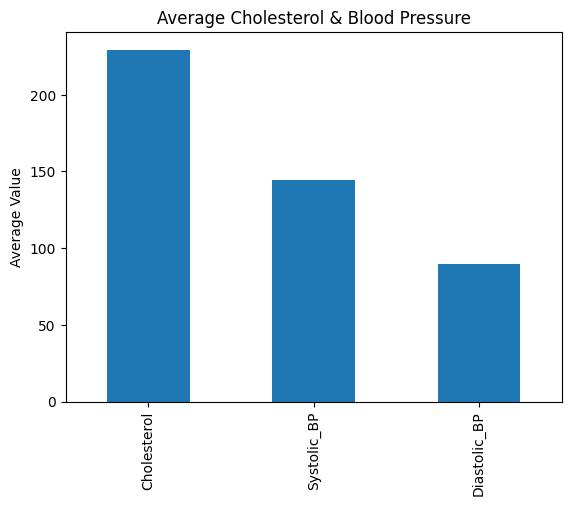

In [11]:
avg_values.plot(kind="bar", title="Average Cholesterol & Blood Pressure")
plt.ylabel("Average Value")
plt.show()


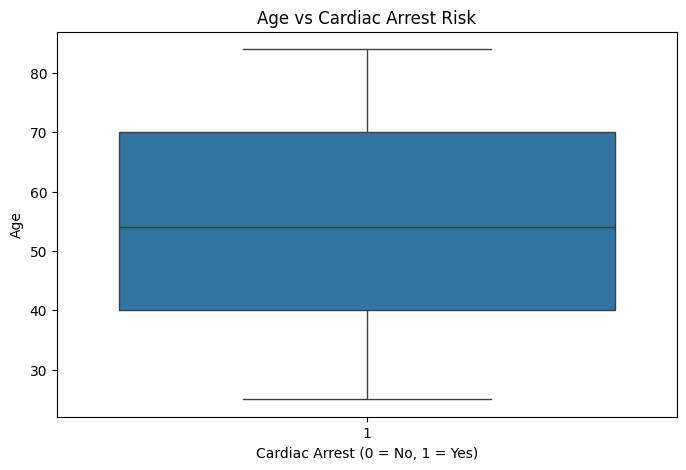

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Cardiac_Arrest", y="Age", data=df)
plt.title("Age vs Cardiac Arrest Risk")
plt.xlabel("Cardiac Arrest (0 = No, 1 = Yes)")
plt.show()


In [13]:
medical_cols = [
    "Age", "BMI", "Systolic_BP", "Diastolic_BP",
    "Cholesterol", "Heart_Rate", "Sleep_Hours",
    "Oxygen_Saturation", "Stress_Level", "Cardiac_Arrest"
]

plt.figure(figsize=(10,7))
sns.heatmap(df[medical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'Low'

<Figure size 1000x700 with 0 Axes>

In [ ]:
sns.countplot(x="Smoking", hue="Cardiac_Arrest", data=df)
plt.title("Smoking vs Cardiac Arrest")
plt.show()


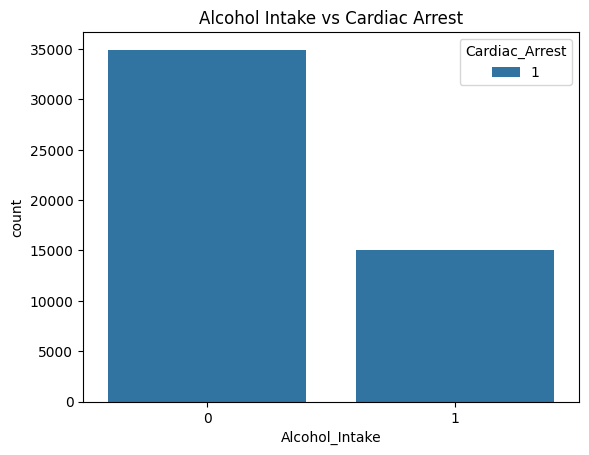

In [44]:
sns.countplot(x="Alcohol_Intake", hue="Cardiac_Arrest", data=df)
plt.title("Alcohol Intake vs Cardiac Arrest")
plt.show()


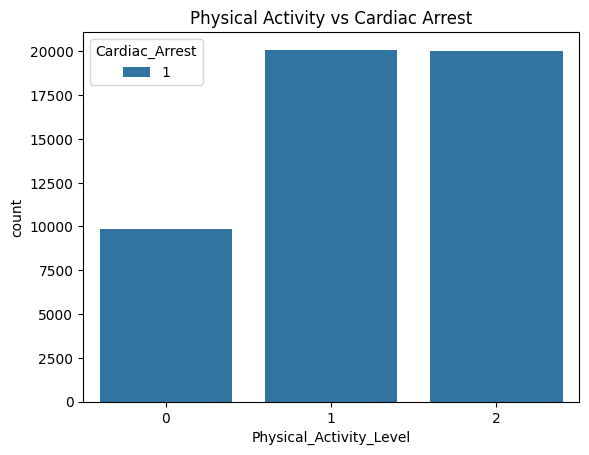

In [46]:
sns.countplot(x="Physical_Activity_Level", hue="Cardiac_Arrest", data=df)
plt.title("Physical Activity vs Cardiac Arrest")
plt.show()


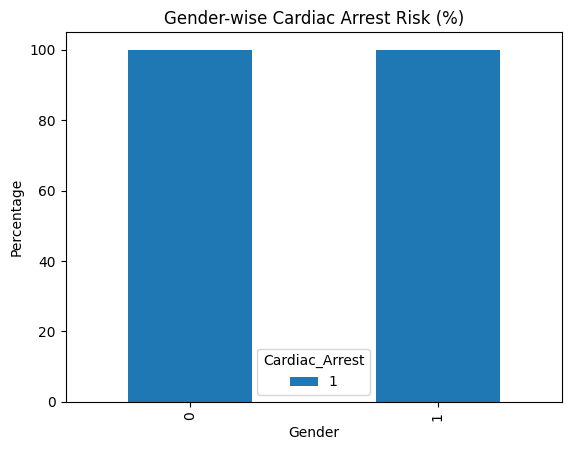

In [48]:
gender_risk = pd.crosstab(df["Gender"], df["Cardiac_Arrest"], normalize="index") * 100
gender_risk.plot(kind="bar", stacked=True)

plt.title("Gender-wise Cardiac Arrest Risk (%)")
plt.ylabel("Percentage")
plt.show()


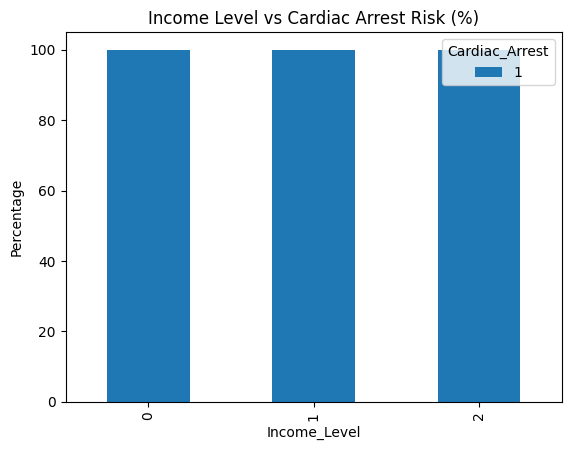

In [50]:
income_risk = pd.crosstab(df["Income_Level"], df["Cardiac_Arrest"], normalize="index") * 100
income_risk.plot(kind="bar", stacked=True)

plt.title("Income Level vs Cardiac Arrest Risk (%)")
plt.ylabel("Percentage")
plt.show()


In [ ]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Middle-Age", "Senior", "Elderly"]
)

age_group_risk = pd.crosstab(df["Age_Group"], df["Cardiac_Arrest"], normalize="index") * 100
age_group_risk.plot(kind="bar", stacked=True)

plt.title("Age Group vs Cardiac Arrest Risk")
plt.ylabel("Percentage")
plt.show()


In [ ]:
risk_summary = df.groupby(
    ["Smoking", "Alcohol_Intake", "Physical_Activity_Level"]
)["Cardiac_Arrest"].mean() * 100

risk_summary.reset_index(name="Cardiac_Risk_%")


In [18]:
df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Smoking,Alcohol_Intake,Physical_Activity_Level,Diet_Type,Diabetes,Family_History,Stress_Level,Sleep_Hours,Heart_Rate,Previous_Heart_Disease,Hypertension,Oxygen_Saturation,Income_Level,Cardiac_Arrest
0,63,Male,22.5,103,96,206,1,0,Moderate,Unhealthy,0,1,Low,8.0,98,0,0,96,Low,1
1,76,Male,22.4,163,114,171,0,0,Low,Healthy,0,0,Low,8.2,87,0,0,99,High,1
2,53,Female,23.4,179,94,200,0,0,Low,Unhealthy,0,0,Medium,5.2,71,0,0,91,Middle,1
3,39,Female,28.4,168,71,201,0,0,Low,Moderate,1,0,Low,6.0,64,0,1,91,Middle,1
4,67,Male,33.4,167,64,260,1,0,High,Moderate,0,0,Medium,6.5,75,0,0,97,Middle,1


In [20]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [22]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols


Index(['Gender', 'Physical_Activity_Level', 'Diet_Type', 'Stress_Level',
       'Income_Level'],
      dtype='object')

In [24]:
lab=LabelEncoder()

In [26]:
for i in df:
    if df[i].dtype=="object":
        df[i]=lab.fit_transform(df[i])

In [28]:
X = df.drop("Cardiac_Arrest", axis=1)
y = df["Cardiac_Arrest"]


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [42]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1